=== Run Sanity Summary ===
ch3ch4 sensor 1: n_samples=19904, n_features=26, n_classes=4
ch3ch4 sensor 2: n_samples=19904, n_features=26, n_classes=4
ch3ch4 sensor 3: n_samples=19904, n_features=26, n_classes=4

=== Top-Feature Overlap Table (stable features first) ===


,feature,overlap_count,rank_spread_within_top,mean_abs,std_abs,cv_abs,rank_ch3ch4 sensor 1,in_top_ch3ch4 sensor 1,rank_ch3ch4 sensor 2,in_top_ch3ch4 sensor 2,rank_ch3ch4 sensor 3,in_top_ch3ch4 sensor 3
0,ch4_form_factor,3,0,0.018558,0.000307,0.016550,10,True,10,True,10,True
1,ch4_spectral_energy,3,0,0.028220,0.000578,0.020467,6,True,6,True,6,True
2,ch3_rms,3,0,0.022736,0.000498,0.021914,7,True,7,True,7,True
3,ch4_spectral_spread,3,1,0.029655,0.000185,0.006226,5,True,4,True,5,True
4,ch3_ptp,3,1,0.034728,0.000741,0.021344,2,True,1,True,2,True
5,ch3_spectral_spread,3,1,0.020486,0.000441,0.021528,9,True,8,True,9,True
6,ch3_spectral_entropy,3,1,0.021140,0.000504,0.023843,8,True,9,True,8,True
7,ch4_ptp,3,1,0.029976,0.000984,0.032835,4,True,5,True,4,True
8,ch3_spectral_energy,3,2,0.034184,0.000797,0.023304,1,True,2,True,3,True
9,frequency_hz,3,2,0.033882,0.001391,0.041046,3,True,3,True,1,True



=== Pairwise Stability Metrics (Top-N Jaccard + Rank Drift) ===
ch3ch4 sensor 1 vs ch3ch4 sensor 2: Jaccard=1.000, shared_topN=10, mean_rank_drift=0.60
ch3ch4 sensor 1 vs ch3ch4 sensor 3: Jaccard=1.000, shared_topN=10, mean_rank_drift=0.40
ch3ch4 sensor 2 vs ch3ch4 sensor 3: Jaccard=1.000, shared_topN=10, mean_rank_drift=0.80

Shared across all 3 runs (Top-10 intersection size): 10
Shared features across all runs:
  - ch3_ptp
  - ch3_rms
  - ch3_spectral_energy
  - ch3_spectral_entropy
  - ch3_spectral_spread
  - ch4_form_factor
  - ch4_ptp
  - ch4_spectral_energy
  - ch4_spectral_spread
  - frequency_hz


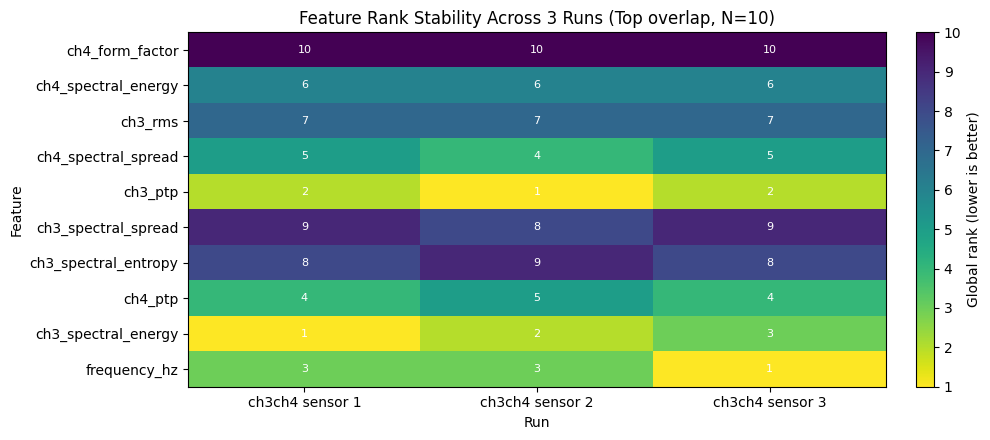


Interpretation hint:
- Higher Jaccard and lower mean_rank_drift indicate better run-to-run SHAP stability.
- overlap_count=3 with small rank_spread_within_top is a strong repeatability signal.


In [5]:
import sys
from pathlib import Path
from itertools import combinations
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add the project root to Python path
project_root = Path(__file__).parent.parent if '__file__' in globals() else Path.cwd().parent
sys.path.append(str(project_root))

from ml_toolbox.data_loader import create_label_to_class_map

saved_models_dir = project_root / "notebooks" / "test_output" / "history"
sensor_names = ["ch3ch4 sensor 1", "ch3ch4 sensor 2", "ch3ch4 sensor 3"]
cache_key = "845ffaffcc21e51b1bb2d9dac25e286f8f48ca72ae0be35fa44257f23d9e27a9"
top_n = 10

def _require_file(path, sensor_name, artifact_name):
    if not path.exists():
        raise FileNotFoundError(
            f"[{sensor_name}] Missing {artifact_name} cache file: {path}"
        )

def _extract_class_shap(shap_values, class_idx):
    if isinstance(shap_values, list):
        if class_idx < 0 or class_idx >= len(shap_values):
            raise ValueError(
                f"class_idx={class_idx} out of range for SHAP list with {len(shap_values)} classes."
            )
        return np.asarray(shap_values[class_idx])

    shap_arr = np.asarray(shap_values)
    if shap_arr.ndim == 3:
        if class_idx < 0 or class_idx >= shap_arr.shape[2]:
            raise ValueError(
                f"class_idx={class_idx} out of range for SHAP array with shape {shap_arr.shape}."
            )
        return shap_arr[..., class_idx]
    if shap_arr.ndim == 2:
        if class_idx != 0:
            raise ValueError(
                f"2D SHAP output supports only class_idx=0, got class_idx={class_idx}."
            )
        return shap_arr
    raise ValueError(f"Unsupported SHAP format with shape {shap_arr.shape}.")

def _compute_shap_aggregates(shap_res, labels, unique_labels):
    labels_arr = np.asarray(labels)
    folds = shap_res.get("shap_values_per_fold", [])
    if len(folds) == 0:
        raise ValueError("shap_res['shap_values_per_fold'] is empty.")

    mean_abs_shap_per_class = []
    mean_signed_shap_per_class = []

    for class_idx, target_label in enumerate(unique_labels):
        shap_vals_class_all = []
        shap_vals_class_signed = []

        for fold_no, fold in enumerate(folds):
            if "shap_values" not in fold or "val_idx" not in fold:
                raise KeyError(
                    f"Fold {fold_no} must contain 'shap_values' and 'val_idx' keys."
                )

            shap_matrix = _extract_class_shap(fold["shap_values"], class_idx)
            val_idx = np.asarray(fold["val_idx"])

            if shap_matrix.ndim != 2:
                raise ValueError(
                    f"Fold {fold_no}: expected 2D SHAP matrix, got shape {shap_matrix.shape}."
                )
            if shap_matrix.shape[0] != val_idx.shape[0]:
                raise ValueError(
                    f"Fold {fold_no}: SHAP rows ({shap_matrix.shape[0]}) != len(val_idx) ({val_idx.shape[0]})."
                )
            if np.any(val_idx < 0) or np.any(val_idx >= labels_arr.shape[0]):
                raise ValueError(f"Fold {fold_no}: val_idx out of labels bounds.")

            shap_vals_class_all.append(shap_matrix)

            y_true_fold = labels_arr[val_idx]
            class_mask = y_true_fold == target_label
            if np.any(class_mask):
                shap_vals_class_signed.append(shap_matrix[class_mask])

        all_shap_class = np.concatenate(shap_vals_class_all, axis=0)
        mean_abs_shap_per_class.append(np.mean(np.abs(all_shap_class), axis=0))

        if len(shap_vals_class_signed) == 0:
            raise ValueError(
                f"No samples found for class label {target_label} when computing signed SHAP means."
            )
        signed_shap_class = np.concatenate(shap_vals_class_signed, axis=0)
        mean_signed_shap_per_class.append(np.mean(signed_shap_class, axis=0))

    return np.asarray(mean_abs_shap_per_class), np.asarray(mean_signed_shap_per_class)

runs = {}

for sensor_name in sensor_names:
    run_dir = saved_models_dir / sensor_name
    bundle_cache_path = run_dir / f"bundle_{cache_key}.joblib"
    eval_cache_path = run_dir / f"eval_res_{cache_key}.joblib"
    shap_cache_path = run_dir / f"shap_res_{cache_key}.joblib"

    _require_file(bundle_cache_path, sensor_name, "bundle")
    _require_file(eval_cache_path, sensor_name, "eval_res")
    _require_file(shap_cache_path, sensor_name, "shap_res")

    bundle = joblib.load(bundle_cache_path)
    eval_res = joblib.load(eval_cache_path)
    shap_res = joblib.load(shap_cache_path)

    for required_key in ["labels", "features", "feature_names", "win_metadata"]:
        if required_key not in bundle:
            raise KeyError(f"[{sensor_name}] Bundle is missing key: {required_key}")
    if "unique_labels" not in eval_res:
        raise KeyError(f"[{sensor_name}] eval_res is missing key: unique_labels")

    labels = np.asarray(bundle["labels"], dtype=np.int32)
    features = np.asarray(bundle["features"])
    feature_names = list(bundle["feature_names"])
    win_metadata = list(bundle["win_metadata"])
    unique_labels = np.asarray(eval_res["unique_labels"])

    if features.ndim != 2:
        raise ValueError(f"[{sensor_name}] features must be 2D, got shape {features.shape}")
    if features.shape[0] != labels.shape[0]:
        raise ValueError(
            f"[{sensor_name}] Row mismatch: features rows={features.shape[0]} != labels={labels.shape[0]}"
        )
    if features.shape[0] != len(win_metadata):
        raise ValueError(
            f"[{sensor_name}] Row mismatch: features rows={features.shape[0]} != win_metadata={len(win_metadata)}"
        )
    if len(feature_names) != features.shape[1]:
        raise ValueError(
            f"[{sensor_name}] Feature mismatch: len(feature_names)={len(feature_names)} != features columns={features.shape[1]}"
        )
    if unique_labels.size == 0:
        raise ValueError(f"[{sensor_name}] eval_res['unique_labels'] is empty")

    mean_abs_shap_per_class, mean_signed_shap_per_class = _compute_shap_aggregates(
        shap_res=shap_res,
        labels=labels,
        unique_labels=unique_labels,
    )

    label_to_class = create_label_to_class_map(win_metadata)
    class_names = [label_to_class.get(int(lbl), f"Class {int(lbl)}") for lbl in unique_labels]

    avg_abs_shap_all_classes = np.mean(mean_abs_shap_per_class, axis=0)
    avg_signed_shap_all_classes = np.mean(mean_signed_shap_per_class, axis=0)

    ranked_idx = np.argsort(avg_abs_shap_all_classes)[::-1]
    top_n_local = min(top_n, len(ranked_idx))
    top_idx = ranked_idx[:top_n_local]
    top_features = [feature_names[i] for i in top_idx]

    rank_by_feature = {feature_names[idx]: rank + 1 for rank, idx in enumerate(ranked_idx)}
    abs_by_feature = {feature_names[i]: float(avg_abs_shap_all_classes[i]) for i in range(len(feature_names))}
    signed_by_feature = {feature_names[i]: float(avg_signed_shap_all_classes[i]) for i in range(len(feature_names))}

    runs[sensor_name] = {
        "feature_names": feature_names,
        "unique_labels": unique_labels,
        "class_names": class_names,
        "mean_abs_shap_per_class": mean_abs_shap_per_class,
        "mean_signed_shap_per_class": mean_signed_shap_per_class,
        "avg_abs_shap_all_classes": avg_abs_shap_all_classes,
        "avg_signed_shap_all_classes": avg_signed_shap_all_classes,
        "rank_by_feature": rank_by_feature,
        "abs_by_feature": abs_by_feature,
        "signed_by_feature": signed_by_feature,
        "top_features": top_features,
        "n_samples": int(features.shape[0]),
        "n_features": int(features.shape[1]),
        "n_classes": int(unique_labels.size),
    }

# Cross-run compatibility checks
ref_sensor = sensor_names[0]
ref_feature_names = runs[ref_sensor]["feature_names"]
ref_unique_labels = runs[ref_sensor]["unique_labels"]
for sensor_name in sensor_names[1:]:
    if runs[sensor_name]["feature_names"] != ref_feature_names:
        raise ValueError(
            f"Feature-name order mismatch between '{ref_sensor}' and '{sensor_name}'. Comparison is unsafe."
        )
    if not np.array_equal(runs[sensor_name]["unique_labels"], ref_unique_labels):
        raise ValueError(
            f"unique_labels mismatch between '{ref_sensor}' and '{sensor_name}'. Comparison is unsafe."
        )

print("=== Run Sanity Summary ===")
for sensor_name in sensor_names:
    run = runs[sensor_name]
    print(
        f"{sensor_name}: n_samples={run['n_samples']}, n_features={run['n_features']}, n_classes={run['n_classes']}"
    )

# Build overlap/stability table
top_feature_sets = {sensor_name: set(runs[sensor_name]["top_features"]) for sensor_name in sensor_names}
union_top_features = sorted(set().union(*top_feature_sets.values()))

rows = []
for feat in union_top_features:
    row = {"feature": feat}
    in_top_count = 0
    observed_top_ranks = []
    abs_vals = []

    for sensor_name in sensor_names:
        rank = runs[sensor_name]["rank_by_feature"][feat]
        is_in_top = rank <= top_n
        abs_val = runs[sensor_name]["abs_by_feature"][feat]

        row[f"rank_{sensor_name}"] = int(rank)
        row[f"in_top_{sensor_name}"] = bool(is_in_top)
        row[f"abs_{sensor_name}"] = float(abs_val)

        abs_vals.append(abs_val)
        if is_in_top:
            in_top_count += 1
            observed_top_ranks.append(rank)

    if len(observed_top_ranks) >= 2:
        rank_spread = int(max(observed_top_ranks) - min(observed_top_ranks))
    else:
        rank_spread = 0

    mean_abs = float(np.mean(abs_vals))
    std_abs = float(np.std(abs_vals))
    coeff_var_abs = float(std_abs / mean_abs) if mean_abs > 0 else float("inf")

    row["overlap_count"] = int(in_top_count)
    row["rank_spread_within_top"] = rank_spread
    row["mean_abs"] = mean_abs
    row["std_abs"] = std_abs
    row["cv_abs"] = coeff_var_abs
    rows.append(row)

overlap_df = pd.DataFrame(rows)
overlap_df = overlap_df.sort_values(
    by=["overlap_count", "rank_spread_within_top", "cv_abs", "mean_abs"],
    ascending=[False, True, True, False],
).reset_index(drop=True)

display_columns = ["feature", "overlap_count", "rank_spread_within_top", "mean_abs", "std_abs", "cv_abs"]
for sensor_name in sensor_names:
    display_columns.extend([f"rank_{sensor_name}", f"in_top_{sensor_name}"] )

print("\n=== Top-Feature Overlap Table (stable features first) ===")
display(overlap_df[display_columns])

# Pairwise stability metrics
print("\n=== Pairwise Stability Metrics (Top-N Jaccard + Rank Drift) ===")
for left_sensor, right_sensor in combinations(sensor_names, 2):
    left_set = top_feature_sets[left_sensor]
    right_set = top_feature_sets[right_sensor]
    inter = left_set & right_set
    union = left_set | right_set
    jaccard = len(inter) / len(union) if union else 1.0

    if inter:
        drifts = [
            abs(
                runs[left_sensor]["rank_by_feature"][feat]
                - runs[right_sensor]["rank_by_feature"][feat]
            )
            for feat in inter
        ]
        mean_rank_drift = float(np.mean(drifts))
    else:
        mean_rank_drift = float("nan")

    print(
        f"{left_sensor} vs {right_sensor}: "
        f"Jaccard={jaccard:.3f}, shared_topN={len(inter)}, mean_rank_drift={mean_rank_drift:.2f}"
    )

intersection_all = set.intersection(*top_feature_sets.values())
print(f"\nShared across all 3 runs (Top-{top_n} intersection size): {len(intersection_all)}")
if intersection_all:
    print("Shared features across all runs:")
    for feat in sorted(intersection_all):
        print(f"  - {feat}")

# Visual: rank heatmap for most stable overlap candidates
plot_df = overlap_df[overlap_df["overlap_count"] >= 2].head(20).copy()
if plot_df.empty:
    print("\nNo features overlap in at least 2 runs for heatmap visualization.")
else:
    rank_cols = [f"rank_{sensor_name}" for sensor_name in sensor_names]
    rank_matrix = plot_df[rank_cols].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(plot_df))))
    im = ax.imshow(rank_matrix, aspect="auto", cmap="viridis_r")
    ax.set_xticks(np.arange(len(rank_cols)))
    ax.set_xticklabels(sensor_names, rotation=0)
    ax.set_yticks(np.arange(len(plot_df)))
    ax.set_yticklabels(plot_df["feature"].tolist())
    ax.set_title(f"Feature Rank Stability Across 3 Runs (Top overlap, N={top_n})")
    ax.set_xlabel("Run")
    ax.set_ylabel("Feature")

    for i in range(rank_matrix.shape[0]):
        for j in range(rank_matrix.shape[1]):
            ax.text(j, i, f"{int(rank_matrix[i, j])}", ha="center", va="center", color="white", fontsize=8)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Global rank (lower is better)")
    plt.tight_layout()
    plt.show()

print("\nInterpretation hint:")
print("- Higher Jaccard and lower mean_rank_drift indicate better run-to-run SHAP stability.")
print("- overlap_count=3 with small rank_spread_within_top is a strong repeatability signal.")